In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("SIRPetri.jl"))
using .SIRPetri
using DataFrames, CSV, Plots

In [2]:
# Диапазон β
β_range = 0.1:0.05:0.8
γ_fixed = 0.1
tmax = 100.0

results = []
for β in β_range
    net, u0, _ = build_sir_network(β, γ_fixed)
    df = simulate_deterministic(net, u0, (0.0, tmax), saveat = 0.5, rates = [β, γ_fixed])
    peak_I = maximum(df.I)
    final_R = df.R[end]
    push!(results, (β = β, peak_I = peak_I, final_R = final_R))
end

df_scan = DataFrame(results)
CSV.write(datadir("sir_scan.csv"), df_scan)

"/home/serazanacua/work/study/2025-2026/simulation-modeling/study_2025-2026_simulation-modeling/labs/lab06/project/data/sir_scan.csv"

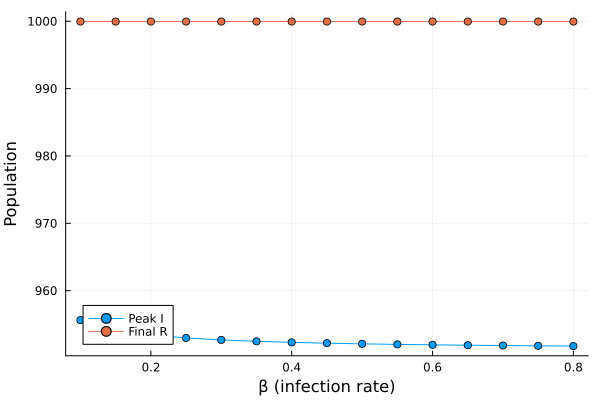

In [3]:
# График
p = plot(
    df_scan.β,
    [df_scan.peak_I df_scan.final_R],
    label = ["Peak I" "Final R"],
    marker = :circle,
    xlabel = "β (infection rate)",
    ylabel = "Population",
)
display(p)